# ViT, CLIP 실습

- Pytorch 표준 ViT 모델 사용
   - 단순화한 ViT 모델 구조 이해
   - ViT 모델 fine-tunning (optional)     
- CLIP 모델 사용한 Zero shot 분류 

# 1.  Pytorch 표준 모델을 이용한 ViT 실험  

## 1) 필요 패키지

In [29]:
import torch
import torch.nn as nn
import torchvision.transforms as T
import torchvision.models as models
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt

## 2) 모델 생성

- 모델 설정 (PyTorch 공식 ViT-Base 16 사용)
    - b/l: base/large, 16/14/32: patch size를 의미 함 
    - ImageNet-1K로 사전 학습된 가중치.

- 이미지 전처리기 PIL to Tensor Pipeline 정의
    - 모델의 입력 크기는 224x224x3  
    - 학습시에는 Dataset과 DataLoader를 사용

In [30]:
# 1. 모델 생성 
weights = models.ViT_B_16_Weights.DEFAULT  # 모델 파라메터 
model = models.vit_b_16(weights=weights) 
model.eval() # 추론 모드 설정

# 2. 이미지 전처리 정의
preprocess = T.Compose([
    T.Resize((224, 224)),  # ViT는 224x224 크기
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), # ImageNet 통계치 
])

## 3) 인터넷에서 이미지 불러오기 (샘플: 골든 리트리버)

In [31]:
img_url = "https://www.borrowmydoggy.com/_next/image?url=https%3A%2F%2Fcdn.sanity.io%2Fimages%2F4ij0poqn%2Fproduction%2Fda89d930fc320dd912a2a25487b9ca86b37fcdd6-800x600.jpg&w=1080&q=80"
response = requests.get(img_url)
img = Image.open(BytesIO(response.content)).convert('RGB')


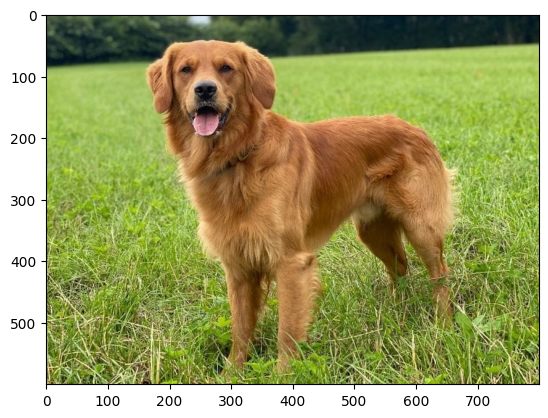

In [32]:
plt.imshow(img)

## 4) 추론

In [33]:
# 4. 이미지 추론
input_tensor = preprocess(img).unsqueeze(0) # 배치 차원 추가 (1, 3, 224, 224)
with torch.no_grad():
    output = model(input_tensor)

# 5. 결과 해석 (Softmax를 통해 확률로 변환)
probabilities = torch.nn.functional.softmax(output[0], dim=0)
top5_prob, top5_catid = torch.topk(probabilities, 5)

# ImageNet 클래스 이름 불러오기
categories = weights.meta["categories"]

## 5) 결과  

Prediction: golden retriever (85.58%)
Prediction: Irish setter (0.93%)
Prediction: Greater Swiss Mountain dog (0.35%)
Prediction: Sussex spaniel (0.33%)
Prediction: Labrador retriever (0.30%)


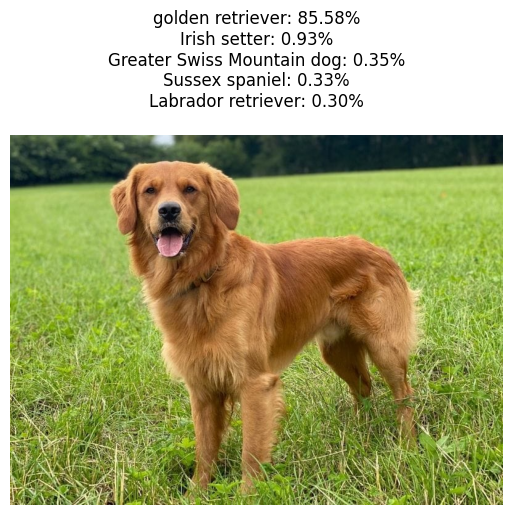

In [34]:
# 6. 결과 시각화
plt.imshow(img)
plt.axis('off')
title_str = ""
for i in range(5):
    label = categories[top5_catid[i]]
    prob = top5_prob[i].item() * 100
    title_str += f"{label}: {prob:.2f}%\n"
    print(f"Prediction: {label} ({prob:.2f}%)")

plt.title(title_str)
plt.show()

## 2. CLIP 실습 
- CLIP 제로샷 분류(Zero-shot Classification): 이미지/텍스트 입력,  전처리,   임베딩 추출,  유사도 계산

In [35]:
import torch
from PIL import Image
import requests
from transformers import CLIPProcessor, CLIPModel

# 1. 디바이스 설정 (GPU 지원 여부 확인)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# 2. Hugging Face로부터 사전학습된 CLIP 모델 및 프로세서 로드
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# 3. 테스트용 샘플 이미지 로드 (인터넷에서 귀여운 고양이 사진을 가져옵니다)
url = "https://images.unsplash.com/photo-1514888286974-6c03e2ca1dba?w=500"
image = Image.open(requests.get(url, stream=True).raw)

# 4. 비교할 텍스트 후보(클래스) 정의
text_labels = ["a photo of a cat", "a photo of a dog", "a photo of a drone", "a photo of a car"]

# 5. 데이터 전처리 (잘못된 인자 제거 완료)
inputs = processor(text=text_labels, images=image, padding=True, return_tensors="pt")
inputs = {k: v.to(device) for k, v in inputs.items()}

# 6. 모델 추론 (기울기 계산 비활성화)
with torch.no_grad():
    outputs = model(**inputs)
    logits_per_image = outputs.logits_per_image 
    probs = logits_per_image.softmax(dim=-1)

# 7. 결과 출력
print("\n--- [CLIP Prediction Results] ---")
for label, prob in zip(text_labels, probs[0]):
    print(f"Label: {label:<20} | Probability: {prob.item() * 100:.2f}%")

Using device: cuda

--- [CLIP Prediction Results] ---
Label: a photo of a cat     | Probability: 99.30%
Label: a photo of a dog     | Probability: 0.69%
Label: a photo of a drone   | Probability: 0.00%
Label: a photo of a car     | Probability: 0.01%


## 3. Toy ViT model

- 단순화한 모델을 통해 내부 구조와 원리를 살펴 봅니다.
1. Rearaange() : Tensor의 차원과 인덱싱을 변환하는 일반적인 함수
    - 예: Rearrange('b c (h p1) (w p2) -> b (h w) (p1 p2 c)', p1=patch_size, p2=patch_size)
    -     bxcxhxw  (4차원) =>  bxcx(hxp1)x(wxp2) => bx(hxw)x (p1xp2xc) (3차원)으로 변환    
2. add Postion Encoding
3. Transformer Layer
4. Forward layer    

In [36]:
import torch
import torch.nn as nn
from einops import repeat
from einops.layers.torch import Rearrange

class ViT(nn.Module):
    def __init__(self, image_size=32, patch_size=4, num_classes=10, dim=128, depth=6, heads=8, mlp_dim=256, channels=3, dropout=0.1):
        super().__init__()
        num_patches = (image_size // patch_size) ** 2
        patch_dim = channels * patch_size ** 2

        # 1. Patch Embedding: 이미지를 패치로 나누고 벡터화
        self.to_patch_embedding = nn.Sequential(
            Rearrange('b c (h p1) (w p2) -> b (h w) (p1 p2 c)', p1=patch_size, p2=patch_size),
            nn.Linear(patch_dim, dim),
        )

        # 2. Learnable Tokens & Positional Encoding
        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, dim))
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim))
        self.dropout = nn.Dropout(dropout)

        # 3. Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(d_model=dim, nhead=heads, dim_feedforward=mlp_dim, dropout=dropout, activation='gelu', batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)

        # 4. MLP Head: 최종 분류기
        self.mlp_head = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, num_classes)
        )

    def forward(self, img):
        x = self.to_patch_embedding(img) # (b, n, dim)
        b, n, _ = x.shape

        # CLS 토큰 추가 및 위치 임베딩 더하기
        cls_tokens = repeat(self.cls_token, '1 1 d -> b 1 d', b=b)
        x = torch.cat((cls_tokens, x), dim=1)
        x += self.pos_embedding
        x = self.dropout(x)

        # Transformer 통과
        x = self.transformer(x)

        # CLS 토큰의 결과만 추출하여 분류
        return self.mlp_head(x[:, 0])


## 모델 학습 (CIFAR-10)

In [37]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

model = ViT()

# 데이터 전처리 및 로드
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=64, shuffle=True)

# 최적화 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# 간단한 학습 루프
for epoch in range(1): # 실습용 1에폭
    for i, (inputs, labels) in enumerate(trainloader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        if i % 100 == 0:
            print(f"Step {i}, Loss: {loss.item():.4f}")

Files already downloaded and verified
Step 0, Loss: 2.3677
Step 100, Loss: 1.9663
Step 200, Loss: 1.9719
Step 300, Loss: 1.7793
Step 400, Loss: 1.7680
Step 500, Loss: 1.6068
Step 600, Loss: 1.5195
Step 700, Loss: 1.4261


# 테스트

Files already downloaded and verified


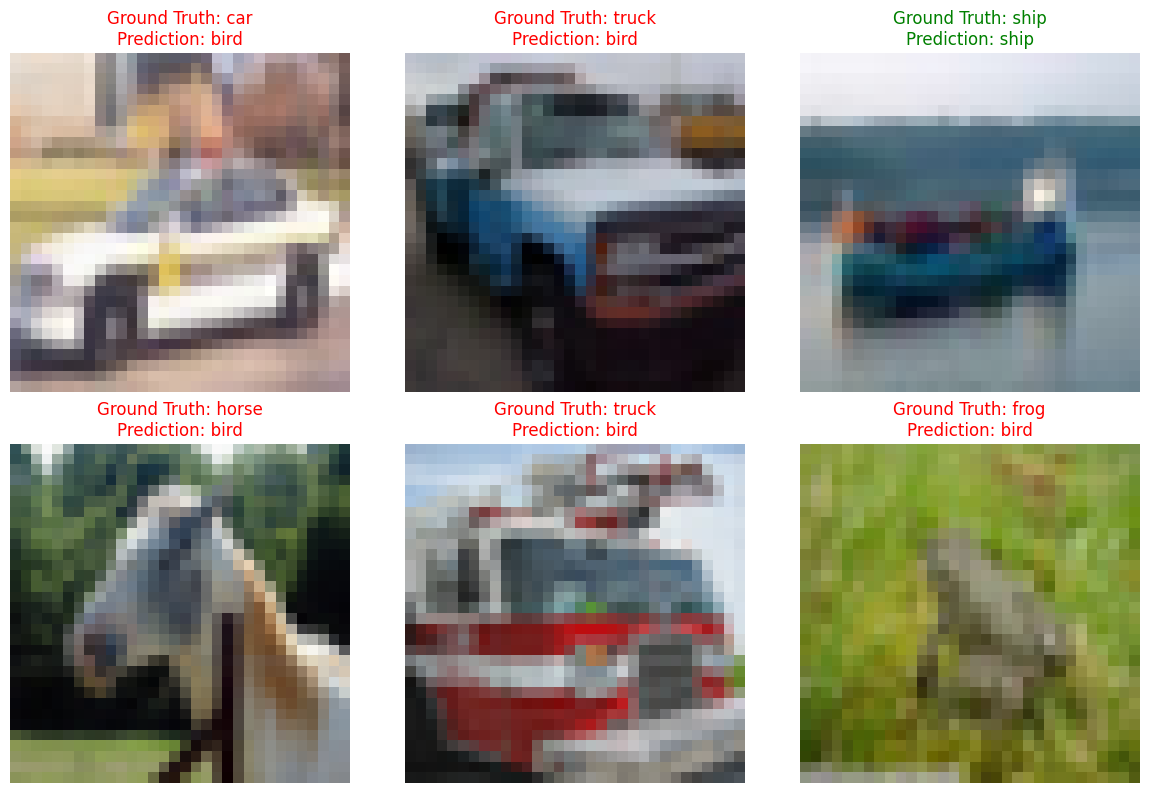

In [38]:
import torch
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# 1. 앞에서 정의한 Scratch ViT 클래스가 선언되어 있어야 합니다.
# (위의 코드를 그대로 사용한다고 가정합니다)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 모델 객체 생성 및 가중치 로드 (학습된 가중치가 있다면 load_state_dict 사용)
# 여기서는 구조만 만든 상태이므로 무작위 예측이 나올 것입니다.
model = ViT(image_size=32, patch_size=4, num_classes=10).to(device)
model.eval()

# 2. 테스트 데이터셋 전처리 (Scratch 모델은 32x32 그대로 사용 가능)
transform = T.Compose([
    T.ToTensor(),
    T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = DataLoader(testset, batch_size=6, shuffle=True)

# CIFAR-10 클래스 이름
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# 3. 데이터 가져오기 및 추론
dataiter = iter(testloader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

# 4. 결과 시각화
plt.figure(figsize=(12, 8))

for i in range(6):
    plt.subplot(2, 3, i + 1)

    # 역정규화 (0.5로 Normalize 했으므로 *0.5 + 0.5)
    img = images[i].cpu().permute(1, 2, 0).numpy()
    img = img * 0.5 + 0.5
    img = np.clip(img, 0, 1)

    plt.imshow(img)

    gt_label = classes[labels[i]]
    pred_label = classes[predicted[i]]

    # 정답이면 초록색, 틀리면 빨간색
    color = 'green' if gt_label == pred_label else 'red'
    plt.title(f"Ground Truth: {gt_label}\nPrediction: {pred_label}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()


# 4.Vit 재학습 (선택 사항)

주의 사항

- 입력 해상도 (Resolution):

   - 공식 ViT 모델은 기본적으로 224x224 이미지에 맞춰져 있습니다.
   - CIFAR-10(32x32) 이미지를 그대로 넣으면 패치로 나눌 때 문제가 생기거나 성능이 매우 낮아집니다. 따라서 transforms.Resize(224)를 반드시 추가해야 합니다.

- 정규화 (Normalization):
    - Pre-trained 모델을 쓸 때는 ImageNet 데이터의 평균과 표준편차로 정규화해야 제 성능이 나옵니다.
   - mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]

-  메모리 문제:
   -  vit_b_16은 파라미터가 약 8,600만 개로 꽤 무겁습니다. 학교 실습실 GPU 메모리가 부족하다면 Batch Size를 줄이거나, 패치 크기가 큰 **vit_b_32**를 권장하세요.

### 모델 구조 확인 방법 

1. print(model)
2. torchinfo로 실제 실행시 메모리 사용양등 상세히 확인

In [39]:
weights = torchvision.models.ViT_B_16_Weights.DEFAULT
model = torchvision.models.vit_b_16(weights=weights)
print(model)

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [27]:
!pip install torchinfo

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [28]:
from torchinfo import summary
weights = torchvision.models.ViT_B_16_Weights.DEFAULT
model = torchvision.models.vit_b_16(weights=weights)
# 입력 데이터의 형태 (Batch_size, Channels, Height, Width)를 같이 넣어줍니다.
summary(model, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                        Output Shape              Param #
VisionTransformer                             [1, 1000]                 768
├─Conv2d: 1-1                                 [1, 768, 14, 14]          590,592
├─Encoder: 1-2                                [1, 197, 768]             151,296
│    └─Dropout: 2-1                           [1, 197, 768]             --
│    └─Sequential: 2-2                        [1, 197, 768]             --
│    │    └─EncoderBlock: 3-1                 [1, 197, 768]             7,087,872
│    │    └─EncoderBlock: 3-2                 [1, 197, 768]             7,087,872
│    │    └─EncoderBlock: 3-3                 [1, 197, 768]             7,087,872
│    │    └─EncoderBlock: 3-4                 [1, 197, 768]             7,087,872
│    │    └─EncoderBlock: 3-5                 [1, 197, 768]             7,087,872
│    │    └─EncoderBlock: 3-6                 [1, 197, 768]             7,087,872
│    │    └─EncoderBlock: 3-7             

In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# GPU 설정 (메모리가 부족할 시 체크)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# -------------------------------------------------------------------
# [주의 사항 1 & 2] 전처리 설정 (Resize 224 및 ImageNet 정규화 기준 적용)
# -------------------------------------------------------------------
train_transform = T.Compose([
    T.Resize((224, 224)), # ViT-B-16 기본 해상도 맞춤
    T.RandomHorizontalFlip(), # 간단한 데이터 증강 추가
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # ImageNet 기준
])

test_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# -------------------------------------------------------------------
# [주의 사항 3] 데이터셋 로드 및 Batch Size 설정
# 실습실 GPU 메모리가 부족하다면 batch_size를 32나 16으로 줄이세요.
# -------------------------------------------------------------------
BATCH_SIZE = 32 

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)
testloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# -------------------------------------------------------------------
# 1. 모델 설정 (Pre-trained ViT-B-16 가져오기 및 헤드 수정)
# -------------------------------------------------------------------
# 만약 메모리가 계속 부족하다면 아래 주석을 풀고 vit_b_32를 사용하세요.
# weights = torchvision.models.ViT_B_32_Weights.DEFAULT
# model = torchvision.models.vit_b_32(weights=weights)

weights = torchvision.models.ViT_B_16_Weights.DEFAULT
model = torchvision.models.vit_b_16(weights=weights)

# *** 기존 ImageNet 1000개 출력을 CIFAR-10의 10개 출력으로 교체 ***
model.heads = nn.Linear(model.hidden_dim, 10)
model = model.to(device)

# 2. 손실 함수 및 최적화 함수 설정
criterion = nn.CrossEntropyLoss()
# ViT 파인튜닝 시에는 대개 아주 작은 Learning Rate(lr)를 사용하는 것이 안정적입니다.
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.01)

# -------------------------------------------------------------------
# 3. 학습 루프 (Training Loop)
# -------------------------------------------------------------------
EPOCHS = 2 # 수업 실습용으로 2에폭만 진행 (필요시 늘리세요)

print("시작: 모델 학습")
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for i, (inputs, labels) in enumerate(trainloader):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        if (i + 1) % 100 == 0:
            print(f"[Epoch {epoch+1}/{EPOCHS}, Step {i+1}/{len(trainloader)}] "
                  f"Loss: {running_loss / 100:.4f} | Train Acc: {100. * correct / total:.2f}%")
            running_loss = 0.0

# -------------------------------------------------------------------
# 4. 테스트 루프 (Evaluation Loop)
# -------------------------------------------------------------------
print("\n시작: 테스트 데이터 검증")
model.eval()
test_correct = 0
test_total = 0

with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        test_total += labels.size(0)
        test_correct += predicted.eq(labels).sum().item()

print(f"\n최종 테스트 정확도 (Test Accuracy): {100. * test_correct / test_total:.2f}%")

# -------------------------------------------------------------------
# 5. 예측 결과 몇 개 시각화하기
# -------------------------------------------------------------------
dataiter = iter(testloader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images)
    _, predicted = outputs.max(1)

plt.figure(figsize=(12, 8))
for i in range(6): # 6개만 출력
    plt.subplot(2, 3, i + 1)
    
    # 이미지 역정규화 및 변환 (matplotlib 시각화용)
    img = images[i].cpu().permute(1, 2, 0).numpy()
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)
    
    plt.imshow(img)
    gt_label = classes[labels[i]]
    pred_label = classes[predicted[i]]
    
    color = 'green' if gt_label == pred_label else 'red'
    plt.title(f"GT: {gt_label}\nPred: {pred_label}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [13]:
import torch
import torchvision.models as models

# 1. 모델 구조만 가져오기 (학습 안 된 상태)
model_scratch = models.vit_b_16(num_classes=10)

# 2. 사전 학습된 가중치와 함께 가져오기 (가장 많이 사용)
# weights=models.ViT_B_16_Weights.DEFAULT는 현재 사용 가능한 가장 좋은 가중치를 의미함
pretrained_vit = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)

# 3. 모델 수정 (Fine-tuning 준비)
# 기본 ViT는 ImageNet용 1000개 클래스이므로, CIFAR-10용으로 마지막 층 교체
import torch.nn as nn
pretrained_vit.heads = nn.Linear(pretrained_vit.hidden_dim, 10)

# 테스트 입력 (ViT-B-16은 기본적으로 224x224 입력을 받음)
dummy_input = torch.randn(1, 3, 224, 224)
output = pretrained_vit(dummy_input)
print(output.shape)  # torch.Size([1, 10])

torch.Size([1, 10])
